Configurando entorno y cargando recursos...


🧠 Congelando base y calibrando modelo con el 40.0% de la señal (Fine-Tuning)...
⏳ Iniciando entrenamiento de calibración...
Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - loss: 2.1118e-04 - val_loss: 0.0011
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - loss: 1.7080e-04 - val_loss: 0.0012
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - loss: 1.6378e-04 - val_loss: 0.0014
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - loss: 1.5954e-04 - val_loss: 0.0011
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - loss: 1.6092e-04 - val_loss: 0.0012
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step - loss: 1.6077e-04 - val_loss: 0.0013

🔍 Ejecutando inferencia neuronal sobre los datos de prueba...
🧹 Filtrando el ruido de alta frecuencia de la IA (Filtro Bessel)...
Calculando Tasa de Error de Bit (BER) y Umbrales PAM-4...
Generando Diagramas de Ojo...


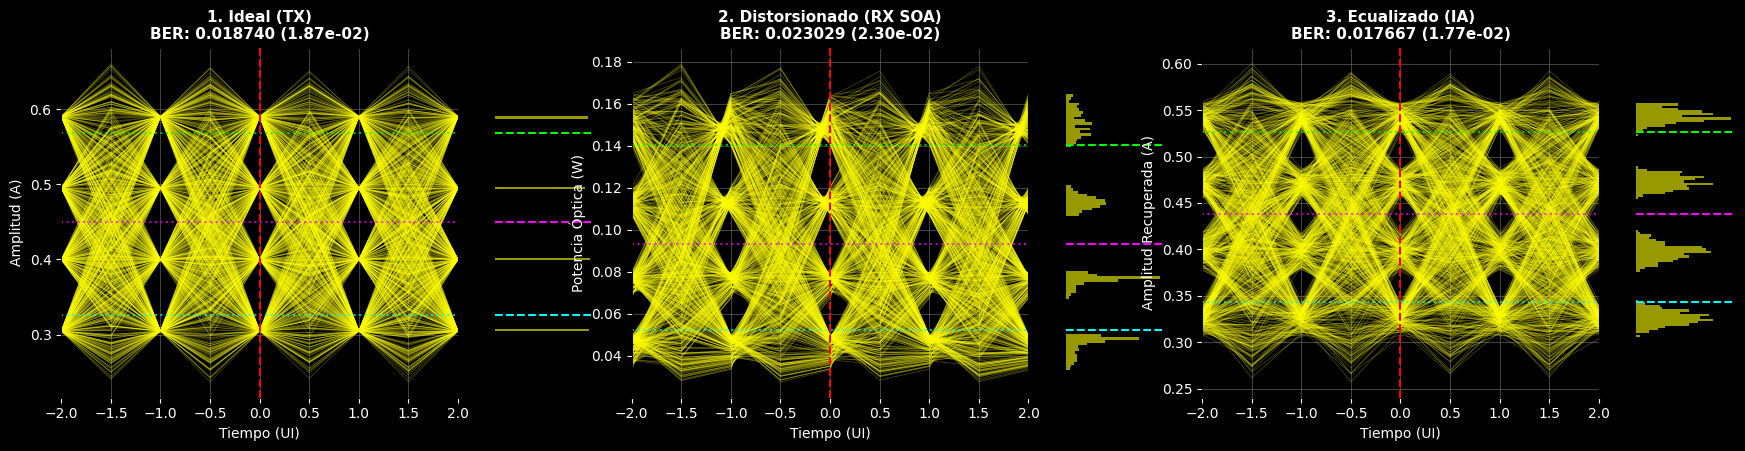


📊 RESULTADOS DE LA ECUALIZACIÓN
❌ Físico (SOA) -> BER: 0.023029 (2.3029e-02)
✅ Neuronal (IA) -> BER: 0.017667 (1.7667e-02)



In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import bessel, filtfilt
import json
import os
from numpy.lib.stride_tricks import sliding_window_view
from tensorflow.keras import layers

# --- 1. CONFIGURACIÓN ---
TEST_FILE = 'datasets' # <--- PON LA RUTA DE TU PARQUET AQUÍ
MODEL_PATH = 'teacher_soa_resnet.keras' 
SCALERS_PATH = 'scalers.json'

WINDOW_SIZE = 128
UI_SAMPLES = 2  
NUM_TRACES = 1000 
FEATURES = ['Output_P2', 'Bit_Rate', 'Beta_RC', 'Rango_Corr']
TARGET_COL = 'I_trim'
FINE_TUNE_PERCENT = 0.40 

# --- 2. CAPA DE ATENCIÓN ---
@tf.keras.utils.register_keras_serializable()
class SimpleAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = layers.Dense(self.units, activation='tanh')
        self.V = layers.Dense(1)
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = self.V(self.W(inputs))
        attention_weights = tf.nn.softmax(score, axis=1)
        return tf.reduce_sum(attention_weights * inputs, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

# --- 3. FUNCIONES AUXILIARES DE RENDERIZADO, FILTRADO Y ESTADÍSTICA ---

def aplicar_filtro_bessel(signal, ui_samples, cutoff_ratio=0.75):
    """Aplica un filtro pasa-bajas de Bessel para suavizar el ruido de alta frecuencia en transiciones."""
    nyquist = ui_samples / 2.0
    baud_rate = 1.0  
    corte_normalizado = (cutoff_ratio * baud_rate) / nyquist
    corte_normalizado = min(corte_normalizado, 0.99)
    
    b, a = bessel(N=4, Wn=corte_normalizado, btype='low', analog=False)
    senal_filtrada = filtfilt(b, a, signal)
    return senal_filtrada

def get_optimal_offset(signal, UI, span_ui):
    """Encuentra la fase de máxima varianza para auto-centrar el ojo en la línea de decisión."""
    if len(signal) < UI: return 0
    vars_per_phase = [np.var(signal[off::UI]) for off in range(UI)]
    best_phase = np.argmax(vars_per_phase)
    center_idx = (span_ui * UI) // 2
    return (best_phase - center_idx) % UI

def plot_single_eye_with_hist(ax_eye, ax_hist, signal, UI, title, ylabel, unit_scale, offset_samples, umbrales_decision=None):
    span_ui = 4 
    samples_span = span_ui * UI
    
    sig_s = signal[offset_samples:]
    if len(sig_s) < samples_span + 1: return
        
    windows = sliding_window_view(sig_s * unit_scale, samples_span + 1)
    eye_m = windows[::samples_span] 
    
    n_traces_plot = min(len(eye_m), NUM_TRACES)
    eye_m = eye_m[:n_traces_plot]
    t_span = np.arange(samples_span + 1) / UI - span_ui / 2.0
    
    # Ploteo del Ojo
    ax_eye.plot(t_span, eye_m.T, color='#FFFF00', alpha=0.3, linewidth=0.5)
    ax_eye.axvline(0, color='r', linestyle='--', linewidth=1.5, zorder=10)
    
    colores_th = ['cyan', 'magenta', 'lime']
    if umbrales_decision is not None:
        for i, umbral in enumerate(umbrales_decision):
            c = colores_th[i % len(colores_th)]
            ax_eye.axhline(umbral, color=c, linestyle=':', linewidth=1.5, alpha=0.7)

    ax_eye.set_facecolor('black')
    ax_eye.set_title(title, color='white', fontweight='bold', fontsize=11)
    ax_eye.set_ylabel(ylabel, color='white')
    ax_eye.set_xlabel('Tiempo (UI)', color='white')
    ax_eye.tick_params(colors='white')
    ax_eye.grid(True, color='gray', alpha=0.5)
    ax_eye.set_xlim([-span_ui/2, span_ui/2])
    
    # Ploteo del Histograma
    center_idx = samples_span // 2
    ax_hist.hist(eye_m[:, center_idx], bins=100, color='#FFFF00', alpha=0.6, orientation='horizontal')
    
    if umbrales_decision is not None:
        for i, umbral in enumerate(umbrales_decision):
            c = colores_th[i % len(colores_th)]
            ax_hist.axhline(umbral, color=c, linestyle='--', linewidth=1.5, zorder=10)
        
    ax_hist.set_facecolor('black')
    ax_hist.axis('off')

def unnormalize_col(scaled_data, scalers, col_name):
    v_min, v_max = scalers['min'][col_name], scalers['max'][col_name]
    return scaled_data * (v_max - v_min + 1e-7) + v_min

def sym2bits(s_arr):
    """Convierte un arreglo de símbolos PAM-4 (0, 1, 2, 3) a bits usando Código Gray."""
    b_msb = (s_arr == 2) | (s_arr == 3)
    b_lsb = (s_arr == 1) | (s_arr == 2)
    return np.column_stack((b_msb, b_lsb)).ravel()

def calcular_ber_optima_estadistica(y_true, y_pred):
    """Calcula la Tasa de Error de Bit (BER) óptima usando decodificación Gray y umbrales Gaussianos."""
    y_t_n = (y_true - y_true.min()) / (y_true.max() - y_true.min() + 1e-7)
    y_p_n = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min() + 1e-7)

    best_ber = 1.0
    best_delay = 0
    best_ths_norm = [0.25, 0.50, 0.75] 

    for d in sorted(range(-5, 6), key=abs):
        if d > 0:
            t, p = y_t_n[d:], y_p_n[:-d]
        elif d < 0:
            t, p = y_t_n[:d], y_p_n[-d:]
        else:
            t, p = y_t_n, y_p_n

        niveles = [
            p[t < 0.16],
            p[(t >= 0.16) & (t < 0.5)],
            p[(t >= 0.5) & (t < 0.83)],
            p[t >= 0.83]
        ]

        th_calculados = []
        for i in range(3):
            if len(niveles[i]) > 0 and len(niveles[i+1]) > 0:
                mu0, sg0 = np.mean(niveles[i]), np.std(niveles[i])
                mu1, sg1 = np.mean(niveles[i+1]), np.std(niveles[i+1])
                th = (sg0 * mu1 + sg1 * mu0) / (sg0 + sg1 + 1e-9)
                th_calculados.append(th)
            else:
                th_calculados.append((i + 1) * 0.25)

        sym_t = np.digitize(t, [(i + 1) * 0.25 for i in range(3)]) 
        sym_p = np.digitize(p, th_calculados) 
        
        # Calcular directamente el BER (Error de Bits)
        curr_ber = np.mean(sym2bits(sym_t) != sym2bits(sym_p))
        
        if curr_ber < best_ber:
            best_ber = curr_ber
            best_delay = d
            best_ths_norm = th_calculados
            
    umbrales_reales = [th * (y_pred.max() - y_pred.min()) + y_pred.min() for th in best_ths_norm]
    return best_ber, best_delay, umbrales_reales

# --- 4. EJECUCIÓN PRINCIPAL ---
if __name__ == "__main__":
    print("Configurando entorno y cargando recursos...")

    # Parche M1
    if not hasattr(tf.keras.layers.Dense, '_parche_aplicado'):
        original_dense_from_config = tf.keras.layers.Dense.from_config
        @classmethod
        def patched_dense_from_config(cls, config):
            if 'quantization_config' in config:
                del config['quantization_config']
            return original_dense_from_config(config)
        tf.keras.layers.Dense.from_config = patched_dense_from_config
        tf.keras.layers.Dense._parche_aplicado = True

    teacher_model = tf.keras.models.load_model(
        MODEL_PATH, compile=False, custom_objects={'SimpleAttention': SimpleAttention}
    )

    with open(SCALERS_PATH, 'r') as f:
        scalers = json.load(f)

    df = pd.read_parquet(TEST_FILE)

    x_scaled = np.column_stack([
        (df[col].values.astype(np.float32) - scalers['min'][col]) / (scalers['max'][col] - scalers['min'][col] + 1e-7)
        for col in FEATURES
    ])
    y_real_scaled = (df[TARGET_COL].values.astype(np.float32) - scalers['min'][TARGET_COL]) / (scalers['max'][TARGET_COL] - scalers['min'][TARGET_COL] + 1e-7)

    x_windows = sliding_window_view(x_scaled[:-1], (WINDOW_SIZE, len(FEATURES)))
    x_windows = x_windows.reshape(-1, WINDOW_SIZE, len(FEATURES))

    offset = WINDOW_SIZE // 2
    y_windows_aligned = y_real_scaled[offset : offset + len(x_windows)]

    split_idx = int(len(x_windows) * FINE_TUNE_PERCENT)
    x_calib, y_calib = x_windows[:split_idx], y_windows_aligned[:split_idx]
    x_infer = x_windows[split_idx:]

    print(f"\n🧠 Congelando base y calibrando modelo con el {FINE_TUNE_PERCENT*100}% de la señal (Fine-Tuning)...")
    for layer in teacher_model.layers[:-2]:
        layer.trainable = False

    teacher_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    
    print("⏳ Iniciando entrenamiento de calibración...")
    teacher_model.fit(x_calib, y_calib, epochs=25, batch_size=256, validation_split=0.15, callbacks=[early_stop], verbose=1)
    
    print("\n🔍 Ejecutando inferencia neuronal sobre los datos de prueba...")
    y_pred_scaled = teacher_model.predict(x_infer, batch_size=1024, verbose=0).flatten()

    prediccion_final_cruda = unnormalize_col(y_pred_scaled, scalers, TARGET_COL)
    
    print("🧹 Filtrando el ruido de alta frecuencia de la IA (Filtro Bessel)...")
    prediccion_final = aplicar_filtro_bessel(prediccion_final_cruda, UI_SAMPLES, cutoff_ratio=0.85)

    start_infer_idx = offset + split_idx
    end_infer_idx = start_infer_idx + len(prediccion_final)

    ideal_alineado = df['I_trim'].values[start_infer_idx : end_infer_idx]
    distorsionado_alineado = df['Output_P2'].values[start_infer_idx : end_infer_idx]

    # --- CÁLCULO DE BER Y UMBRALES ---
    print("Calculando Tasa de Error de Bit (BER) y Umbrales PAM-4...")
    
    ber_id, delay_id, ths_id = calcular_ber_optima_estadistica(ideal_alineado, ideal_alineado) 
    ber_soa, delay_soa, ths_soa = calcular_ber_optima_estadistica(ideal_alineado, distorsionado_alineado)
    ber_ia, delay_ia, ths_ia = calcular_ber_optima_estadistica(ideal_alineado, prediccion_final)

    # --- RENDERIZADO VISUAL ---
    print("Generando Diagramas de Ojo...")

    fig = plt.figure(figsize=(18, 5), facecolor='black')
    gs = gridspec.GridSpec(1, 6, width_ratios=[4, 1, 4, 1, 4, 1], wspace=0.15)

    # Añadido el doble formato en los títulos de la gráfica
    senales = [
        (ideal_alineado, f"1. Ideal (TX)\nBER: {ber_id:.6f} ({ber_id:.2e})", "Amplitud (A)", ths_id),
        (distorsionado_alineado, f"2. Distorsionado (RX SOA)\nBER: {ber_soa:.6f} ({ber_soa:.2e})", "Potencia Óptica (W)", ths_soa),
        (prediccion_final, f"3. Ecualizado (IA)\nBER: {ber_ia:.6f} ({ber_ia:.2e})", "Amplitud Recuperada (A)", ths_ia)
    ]

    for i, (sig, title, ylabel, umbrales_calc) in enumerate(senales):
        ax_eye = plt.subplot(gs[0, i*2])
        ax_hist = plt.subplot(gs[0, i*2 + 1], sharey=ax_eye)
        
        offset_auto = get_optimal_offset(sig, UI_SAMPLES, 4)
        plot_single_eye_with_hist(ax_eye, ax_hist, sig, UI_SAMPLES, title, ylabel, 1.0, offset_auto, umbrales_calc)

    plt.subplots_adjust(left=0.05, right=0.98, top=0.85, bottom=0.15)
    plt.show()

    print("\n" + "="*65)
    print("📊 RESULTADOS DE LA ECUALIZACIÓN")
    print("="*65)
    # Formato decimal con 6 dígitos y científico con 4 dígitos
    print(f"❌ Físico (SOA) -> BER: {ber_soa:.6f} ({ber_soa:.4e})")
    print(f"✅ Neuronal (IA) -> BER: {ber_ia:.6f} ({ber_ia:.4e})")
    print("="*65 + "\n")